# Introduction

Idea is to fit a *single GEV distribution* using annual maxima from **multiple years (pooled together)**, not separate GEVs for each year

**Notes on next steps:**
- 8 models × 680 locations = 5,440 independent analyses >> parallelize code on model level

Estimated Time
|Workers | Estimated Time | Speedup| 
|---| ---| ---| 
|1 core (sequential) | ~45-60 minutes | 1x baseline| 
|3 cores | ~15-20 minutes | ~3x faster| 
| 4 cores | ~12-15 minutes | ~4x faster|


**!!! ToDo**
- Plot model fits
- Store model parameters in txt
- create a mapping function for location info and lat/lon... store as JSON to save lookup

# Import Libraries

In [ ]:
from typing import Dict, Optional
from glob import glob
import psutil
import multiprocessing as mp
import time
from datetime import datetime

from tqdm import tqdm
import pickle
from pathlib import Path

from pandas import DataFrame, concat
from numpy import (
    ndarray, sum, log, ndarray, full_like, any, inf, 
    exp 
    )
from scipy import stats
from scipy.optimize import minimize
import random

import matplotlib.pyplot as plt

from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from time import sleep

import func_preparation as dbf
import func_stationary as dbst
import func_plotting as dbplt


# Settings

In [3]:
path = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/'

In [4]:
hindcast_start = 1960
hindcast_end = 2019

In [5]:
geolocator = Nominatim(user_agent="geo_lookup")

In [6]:
colors = ['#7FF9F7FF', '#0B2483FF','#0F8CDEFF','#4C4CFFFF','#040509FF','#23B4DCFF','#3C7084FF']

In [7]:
# For code parallelization later in the process 
print(f"Physical cores: {psutil.cpu_count(logical=False)}")
print(f"Logical cores: {psutil.cpu_count(logical=True)}")
print(f"Logical cores (mp): {mp.cpu_count()}")

Physical cores: 4
Logical cores: 8
Logical cores (mp): 8


# Import data

In [8]:
ls_files = [file for file in glob(path + '*.nc')]

test_models = ls_files[:3]

In [9]:
dic_data_per_model = dict()

for en, file in enumerate(test_models):
    model_name = file.split('/')[-1].split('.nc')[0].split('_')[-1]
    
    print(f'Importing data from model {model_name} ({en+1}/{len(ls_files)})...')
    model_name, ds_model = dbf.import_data_from_file(file) 
    
    dic_data_per_model[model_name] = dict({'raw data': ds_model})

Importing data from model MIROC6 (1/8)...
Importing data from model MPI-ESM1-2-HR (2/8)...
Importing data from model HadGEM3-GC31-MM (3/8)...


# Data Preparation 

BiasCorrection and Selection of valid data

In [10]:
en = 0 
for model_name, dic_data_model in dic_data_per_model.items():
    print(f'Processing model: {model_name} ({en+1}/{len(ls_files)})...')

    ds_model_corrected = dbf.bias_correction(dic_data_model['raw data'])
    dbf.verify_bias_correction(dic_data_model['raw data'], ds_model_corrected)
    print(f'\tBias correction successfully done and verified.')

    data_valid, sites_valid, sites_total, rate_invalid = dbf.select_valid_data(
        dic_data_model['raw data'], ds_model_corrected
    )
    print(
        f" - Site Selection done:\n"
        f"\tFrom {sites_total} sites, {sites_valid} are model_valid – removed {rate_invalid:.2f}% invalid sites."
    )
    
    dic_data_per_model[model_name]['valid data'] = data_valid
    dic_data_per_model[model_name]['preparation info'] = sites_valid, sites_total, rate_invalid
    en += 1
    print("-------------------------------------------------------------------------------------")
    print("")

Processing model: MIROC6 (1/8)...
 - Validating bias correction:
	Asserting whether actual ([0.31648891 0.36485006]) selection matches expected selection ([0.31648891 0.36485006])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 7054 are model_valid – removed 36.00% invalid sites.
-------------------------------------------------------------------------------------

Processing model: MPI-ESM1-2-HR (2/8)...
 - Validating bias correction:
	Asserting whether actual ([1.21392833 1.20136832]) selection matches expected selection ([1.21392833 1.20136832])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 5808 are model_valid – removed 47.31% invalid sites.
-------------------------------------------------------------------------------------

Processing model: HadGEM3-GC31-MM (3/8)...
 - Validating bias correction:
	Asserting whether actual ([0.48223098 0.70031818]) selection matches expected selectio

In [11]:
sites_valid = [dic_data_per_model[model_label]['preparation info'][0] for model_label in dic_data_per_model.keys()]

print("Data Overview")
print(
    f"Data is available from {len(test_models)} models (out of {len(ls_files)}) and "
    f"{min(sites_valid)}-{max(sites_valid)} locations"
    f""
)

Data Overview
Data is available from 3 models (out of 8) and 5808-7216 locations


# Workflow stationary GEV

### Utils

In [13]:
def locations_label_lookup_with_cache(
    locations: DataFrame, cache_file: str = "geocoding_cache.pkl", max_retries: int = 3, delay: float = 1.5,
    user_agent: str = "storm_surge_analysis"
    ):
    """
    Geocode locations with caching to resume after interruptions.
    
    If the script fails or is interrupted, you can restart and it will
    continue from where it left off.
    
    Parameters:
    -----------
    locations : DataFrame
        Must have 'lat' and 'lon' columns
    cache_file : str
        File to save progress (default: "geocoding_cache.pkl")
    max_retries : int
        Maximum retry attempts per location
    delay : float
        Delay between requests in seconds
    user_agent : str
        Custom user agent for the geocoder
        
    Returns:
    --------
    list : Location objects (or None for failures)
    """
    geolocator = Nominatim(user_agent=user_agent, timeout=10)
    
    cache_path = Path(cache_file)
    if cache_path.exists():
        with open(cache_file, 'rb') as f:
            cache = pickle.load(f)
        print(f"✓ Loaded cache with {len(cache)} existing results")
    else:
        cache = {}
    
    locations_label = [None] * len(locations)
    failed_indices = []
    
    to_process = [ix for ix in locations.index if ix not in cache]
    already_done = len(locations) - len(to_process)
    
    print(f"Geocoding status:")
    print(f"  Already cached: {already_done}/{len(locations)}")
    print(f"  To process: {len(to_process)}")
    print(f"  Estimated time: ~{len(to_process) * delay / 60:.1f} minutes")
    
    try:
        for ix in tqdm(locations.index, desc="\t\tGeocoding"):
            if ix in cache:
                locations_label[ix] = cache[ix]
                continue
            
            lat = locations.loc[ix, 'lat']
            lon = locations.loc[ix, 'lon']
            
            location = None
            
            for attempt in range(max_retries):
                try:
                    location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
                    break  
                    
                except GeocoderTimedOut:
                    if attempt < max_retries - 1:
                        sleep(2 ** attempt) 
                        continue
                    else:
                        failed_indices.append(ix)
                        
                except GeocoderServiceError:
                    failed_indices.append(ix)
                    break
                    
                except Exception as e:
                    print(f"\n⚠️  Error at index {ix}: {e}")
                    failed_indices.append(ix)
                    break
            
            locations_label[ix] = location
            cache[ix] = location 
            
            if (ix + 1) % 50 == 0:
                with open(cache_file, 'wb') as f:
                    pickle.dump(cache, f)
            
            sleep(delay)
    
    except KeyboardInterrupt:
        print("\nInterrupted by user. Saving progress...")
        with open(cache_file, 'wb') as f:
            pickle.dump(cache, f)
        print(f"✓ Progress saved to {cache_file}")
        print(f"  Run again to continue from index {ix}")
        raise
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    
    success_count = sum(1 for loc in locations_label if loc is not None)
    print(f"\n✓ Geocoding complete:")
    print(f"  Success: {success_count}/{len(locations)}")
    print(f"  Failed: {len(failed_indices)}")
    
    return locations_label


def locations_label_lookup_batched(
    locations: DataFrame,
    batch_size: int = 100,
    cache_file: str = "geocoding_cache.pkl",
    delay: float = 1.5
):
    """
    Geocode locations in batches with caching by (lat, lon).

    Parameters
    ----------
    locations : pd.DataFrame
        Must have 'lat' and 'lon' columns.
    batch_size : int
        Number of locations to process per batch.
    cache_file : str
        Path to cache file for saving progress.
    delay : float
        Delay in seconds between geocoding requests.

    Returns
    -------
    List
        List of geopy Location objects or None for failures, in the same order as `locations`.
    """
    
    cache_path = Path(cache_file)
    if cache_path.exists():
        with open(cache_file, 'rb') as f:
            cache = pickle.load(f)
        print(f"\t✓ Loaded {len(cache)} cached results")
    else:
        cache = {}

    geolocator = Nominatim(user_agent="storm_surge_analysis", timeout=10)
    
    total_batches = (len(locations) + batch_size - 1) // batch_size

    for batch_num in range(total_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, len(locations))
        print(f"\tProcessing batch {batch_num + 1}/{total_batches} (locations {start_idx}-{end_idx})")
        
        for ix in tqdm(range(start_idx, end_idx), desc=f"\tBatch {batch_num + 1}"):
            lat = locations.loc[ix, 'lat']
            lon = locations.loc[ix, 'lon']
            key = (lat, lon)
            
            if key in cache:
                continue  # already cached

            try:
                location = geolocator.reverse((lat, lon), exactly_one=True)
                cache[key] = location
            except Exception as e:
                print(f"\n⚠️  Error at {key}: {e}")
                cache[key] = None
            
            sleep(delay)
        
        # Save cache after each batch
        with open(cache_file, 'wb') as f:
            pickle.dump(cache, f)
        print(f"\t✓ Batch {batch_num + 1} saved to cache")
    
    # Map back to input order
    locations_label = [cache.get((lat, lon)) for lat, lon in zip(locations['lat'], locations['lon'])]
    
    success_count = sum(1 for loc in locations_label if loc is not None)
    print(f"\t✓ All batches complete: {success_count}/{len(locations)} successful")
    
    return locations_label


def locations_label_lookup(locations: DataFrame):
    locations_label = []
    time_outs = []
    to = 0
    for ix in locations.index:
        lat = locations.loc[ix, 'lat']
        lon = locations.loc[ix, 'lon']
        
        try:
            location = geolocator.reverse((lat, lon), exactly_one=True)
        except GeocoderTimedOut:
            print(f"Timeout at index {ix}, retrying...")
            time_outs = to
            to +=1
            sleep(1)
            location = geolocator.reverse((lat, lon), exactly_one=True)
        
        locations_label.append(location)
        sleep(1) 
    return locations_label

In [14]:
def prepare_data(data: DataFrame, hindcast_start:int, hindcast_end: int) -> DataFrame:
        """Calculate target years and filter to hindcast period."""
        data['target_year'] = data['sim_year'] + data['lead']

        mask = (data['target_year'] >= hindcast_start) & \
                (data['target_year'] <= hindcast_end)
        data_hindcast = data[mask].copy()

        print(f"\nData Summary:")
        print(f"  Hindcast period: {hindcast_start}-{hindcast_end}")
        print(f"  Total observations: {len(data_hindcast):,}")
        print(f"  Models: {data_hindcast['model'].nunique()}")
        print(f"  Locations: {min(data_hindcast[['lon', 'lat']].nunique().values)}")
        
        return data_hindcast

In [15]:
def extract_annual_maxima(data_hindcast: DataFrame, model: str, lon: float, lat: float) -> DataFrame:
    """
    Extract annual maxima for a specific model-location combination.
    
    For each target year, takes maximum across all sim_year+lead combos.
    """

    subset = data_hindcast[
        (data_hindcast['model'] == model) & 
        (data_hindcast['lon'] == lon) &
        (data_hindcast['lat'] == lat)
    ].copy()

    if len(subset) == 0:
        return DataFrame(columns=['year', 'annual_max'])
    
    annual_max = subset.groupby('target_year')['storm_surge'].max().reset_index()
    annual_max.columns = ['year', 'annual_max']
    
    return annual_max.sort_values('year')


def fit_stationary_gev(data: ndarray) -> Dict:
    """
    Fit stationary GEV using Maximum Likelihood Estimation.
    
    This assumes GEV parameters are constant over time.
    RECOMMENDED: Use when you have 60+ years × 2 members = 120 points
    
    Parameters:
    -----------
    data : np.ndarray
        Annual maxima values
        
    Returns:
    --------
    dict : GEV parameters and diagnostics
    """
    if len(data) < 10:
        print(f"Warning: Only {len(data)} observations. Need at least 10 for reliable GEV fit.")
        return None
    
    try:
        c, loc, scale = stats.genextreme.fit(data)
        shape = -c 
        
        ll = sum(stats.genextreme.logpdf(data, c, loc, scale))
        
        n_params = 3
        aic = 2 * n_params - 2 * ll
        bic = log(len(data)) * n_params - 2 * ll
        
        if abs(shape) < 0.05:
            dist_type, tail = "Gumbel (Type I)", "Exponential"
        elif shape > 0:
            dist_type, tail = "Fréchet (Type II)", "Heavy (polynomial)"
        else:
            dist_type, tail = "Weibull (Type III)", "Light (bounded)"

        return {
            'shape': shape,
            'location': loc,
            'scale': scale,
            'n_obs': len(data),
            'log_likelihood': ll,
            'aic': aic,
            'bic': bic,
            'dist_type': dist_type,
            'tail_behavior': tail
        }
    except Exception as e:
        print(f"Failed to conduct GEV fitting due to error: {e}")
        return None

In [16]:
def fit_nonstationary_gev(
    years: ndarray, data: ndarray, trend_params: str = 'location'
    ) -> Dict:
    """
    Fit non-stationary GEV where parameters vary linearly with time.
    
    This allows detection of trends in extreme values.
    RECOMMENDED: Use to test if sea level rise affects extremes
    
    Parameters:
    -----------
    years : np.ndarray
        Years corresponding to each observation
    data : np.ndarray
        Annual maxima values
    trend_params : str
        Which parameters have trends: 'location', 'scale', or 'both'
        
    Returns:
    --------
    dict : Non-stationary GEV parameters and diagnostics
    """
    if len(data) < 20:
        print(f"Warning: Non-stationary GEV needs ≥20 obs. Have {len(data)}.")
        return None
    
    t = (years - years.mean()) / years.std()
    
    def neg_log_likelihood(params):
        """Negative log-likelihood for optimization."""
        if trend_params == 'location':
            mu0, mu1, sigma, xi = params
            mu_t = mu0 + mu1 * t
            sigma_t = full_like(t, sigma)
        elif trend_params == 'scale':
            mu, sigma0, sigma1, xi = params
            mu_t = full_like(t, mu)
            sigma_t = sigma0 + sigma1 * t
        elif trend_params == 'both':
            mu0, mu1, sigma0, sigma1, xi = params
            mu_t = mu0 + mu1 * t
            sigma_t = sigma0 + sigma1 * t
        else:
            raise ValueError("trend_params must be 'location', 'scale', or 'both'")
        
        
        if any(sigma_t <= 0):
            return inf
        
        z = (data - mu_t) / sigma_t
        
        if abs(xi) < 1e-10:  # Gumbel case
            ll = -sum(log(sigma_t)) - sum(z) - sum(exp(-z))
        else:
            term = 1 + xi * z
            if any(term <= 0):
                return inf
            ll = (-sum(log(sigma_t)) - 
                    (1 + 1/xi) * sum(log(term)) - 
                    sum(term**(-1/xi)))
        
        return -ll
    
    stationary = fit_stationary_gev(data)
    if stationary is None:
        return None
    
    try:
        if trend_params == 'location':
            x0 = [stationary['location'], 0.0, stationary['scale'], stationary['shape']]
            result = minimize(neg_log_likelihood, x0, method='Nelder-Mead')
            mu0, mu1, sigma, xi = result.x
            params_out = {
                'mu0': mu0, 'mu1': mu1, 'sigma': sigma, 'xi': xi,
                'trend_in': 'location'
            }
            n_params = 4
            
        elif trend_params == 'scale':
            x0 = [stationary['location'], stationary['scale'], 0.0, stationary['shape']]
            result = minimize(neg_log_likelihood, x0, method='Nelder-Mead')
            mu, sigma0, sigma1, xi = result.x
            params_out = {
                'mu': mu, 'sigma0': sigma0, 'sigma1': sigma1, 'xi': xi,
                'trend_in': 'scale'
            }
            n_params = 4
            
        else:  
            x0 = [stationary['location'], 0.0, stationary['scale'], 0.0, stationary['shape']]
            result = minimize(neg_log_likelihood, x0, method='Nelder-Mead')
            mu0, mu1, sigma0, sigma1, xi = result.x
            params_out = {
                'mu0': mu0, 'mu1': mu1, 'sigma0': sigma0, 'sigma1': sigma1, 'xi': xi,
                'trend_in': 'both'
            }
            n_params = 5
        
        ll = -result.fun
        aic = 2 * n_params - 2 * ll
        bic = log(len(data)) * n_params - 2 * ll
        
        params_out.update({
            'n_obs': len(data),
            'log_likelihood': ll,
            'aic': aic,
            'bic': bic,
            'years_mean': years.mean(),
            'years_std': years.std()
        })
        
        return params_out
        
    except Exception as e:
        print(f"Non-stationary GEV fitting error: {e}")
        return None


def calculate_return_levels(
    gev_params: Dict, return_periods: list = [10, 50, 100], year: Optional[float] = None
    ) -> Dict:
    """
    Calculate return levels from GEV parameters.
    
    Parameters:
    -----------
    gev_params : dict
        GEV parameters (stationary or non-stationary)
    return_periods : list
        Return periods in years
    year : float, optional
        For non-stationary: year to calculate return level
        
    Returns:
    --------
    dict : Return levels
    """
    if gev_params is None:
        return None
    
    if 'trend_in' in gev_params:
        if year is None:
            year = gev_params['years_mean']
        
        t = (year - gev_params['years_mean']) / gev_params['years_std']
        
        if gev_params['trend_in'] == 'location':
            mu = gev_params['mu0'] + gev_params['mu1'] * t
            sigma = gev_params['sigma']
            xi = gev_params['xi']
        elif gev_params['trend_in'] == 'scale':
            mu = gev_params['mu']
            sigma = gev_params['sigma0'] + gev_params['sigma1'] * t
            xi = gev_params['xi']
        else:  # both
            mu = gev_params['mu0'] + gev_params['mu1'] * t
            sigma = gev_params['sigma0'] + gev_params['sigma1'] * t
            xi = gev_params['xi']
    else:
        mu = gev_params['location']
        sigma = gev_params['scale']
        xi = gev_params['shape']
    
    return_levels = {}
    for T in return_periods:
        p = 1 - 1/T
        
        if abs(xi) < 1e-10:  # Gumbel
            z_p = mu - sigma * log(-log(p))
        else:
            z_p = mu + (sigma / xi) * ((-log(p))**(-xi) - 1)
        
        return_levels[f'{T}-year'] = z_p
    
    return return_levels


def compare_models(stationary: Dict, nonstationary: Dict) -> Dict:
    """
    Compare stationary vs non-stationary GEV using likelihood ratio test.
    
    Returns:
    --------
    dict : Test results and recommendation
    """
    if stationary is None or nonstationary is None:
        return None
    
    lr_statistic = 2 * (nonstationary['log_likelihood'] - stationary['log_likelihood'])
    
    if nonstationary['trend_in'] in ['location', 'scale']:
        df = 1  
    else:  
        df = 2  
    
    p_value = 1 - stats.chi2.cdf(lr_statistic, df)
    
    delta_aic = nonstationary['aic'] - stationary['aic']
    
    if p_value < 0.05:
        decision = "Non-stationary model is significantly better (p < 0.05)"
        recommendation = "Use non-stationary model - trend detected!"
    elif delta_aic < -2:
        decision = "Non-stationary preferred by AIC (ΔAIC < -2)"
        recommendation = "Use non-stationary model"
    else:
        decision = "No strong evidence for non-stationarity"
        recommendation = "Use stationary model (simpler)"
    
    return {
        'lr_statistic': lr_statistic,
        'df': df,
        'p_value': p_value,
        'delta_aic': delta_aic,
        'delta_bic': nonstationary['bic'] - stationary['bic'],
        'decision': decision,
        'recommendation': recommendation
    }


In [17]:
def analyze_location(data_hindcast:DataFrame, model: str, lat: float, lon: float, location_info: str) -> Dict:
        """
        Complete analysis for one model-location combination.
        Fits both stationary and non-stationary GEV.
        """
        annual_max = extract_annual_maxima(data_hindcast, model=model, lon=lon, lat=lat)

        if len(annual_max) < 10:
                return None

        years = annual_max['year'].values
        data = annual_max['annual_max'].values

        print("\t\tconducting stationary GEV...")
        gev_stationary = fit_stationary_gev(data)
        print(f"\t\t\tstationary GEV done (success {gev_stationary != None}); continuing with non-stationary GEV...")
        gev_nonstat_loc = fit_nonstationary_gev(years, data, 'location')
        print(f"\t\t\tnon-stationary GEV done (success {gev_nonstat_loc != None}).")
        comparison = compare_models(gev_stationary, gev_nonstat_loc)

        rl_stationary = calculate_return_levels(gev_stationary, [10, 25, 50, 100, 200])
        rl_nonstat_start = calculate_return_levels(
                gev_nonstat_loc, [10, 50, 100], year=years.min()
        ) if gev_nonstat_loc else None

        rl_nonstat_end = calculate_return_levels(
                gev_nonstat_loc, [10, 50, 100], year=years.max()
        ) if gev_nonstat_loc else None

        return {
                'model': model,
                'location': (lat, lon),
                'location info': location_info,
                'annual_maxima': annual_max,
                'gev_stationary': gev_stationary,
                'gev_nonstationary': gev_nonstat_loc,
                'model_comparison': comparison,
                'return_levels_stationary': rl_stationary,
                'return_levels_1960': rl_nonstat_start,
                'return_levels_2019': rl_nonstat_end
        }


## Initial try 

### Batch data to 5 locations all years

Create a batch of 5 locations. If this workflow works, we can batch and paralize the rest.

In [18]:
ls_models = list(dic_data_per_model.keys())
ls_models

['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM']

In [19]:
dic_model_valid = dict(
    map(
        lambda ex_model: (ex_model, dic_data_per_model[ex_model]['valid data']),
        ls_models
    )
)

In [20]:
dic_locationsID_per_model = {}

for model_ in dic_model_valid.keys():
    locations_id = []
    while len(locations_id) < 5:
        locations_id.append(random.randint(0, dic_model_valid[model_].shape[-1]))    
    dic_locationsID_per_model[model_] = sorted(locations_id)
    
dic_locationsID_per_model

{'MIROC6': [211, 1237, 1992, 3589, 4089],
 'MPI-ESM1-2-HR': [732, 812, 3629, 5451, 5674],
 'HadGEM3-GC31-MM': [592, 1873, 2280, 5865, 5894]}

In [21]:
dic_batch_locations = {
    model_: dic_model_valid[model_][:, :, dic_locationsID_per_model[model_]] 
    for model_ in dic_model_valid.keys()
    }

In [22]:
dic_data = {}
df = None

for model_ in dic_batch_locations.keys():
    df = dic_batch_locations[model_].to_dataframe(name="value").reset_index()
    df['model'] = model_
    df.rename(columns={'value': 'storm_surge'}, inplace=True)
    dic_data[model_] = df
    
df = concat(dic_data).reset_index()

df.describe()

,level_1,sample,member,sites,sim_year,lead,lon,lat,bc_flag,storm_surge
count,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,16175.000000
mean,3320.354271,331.585427,1.500000,4825.607035,1995.291457,5.500000,2.180368,45.917845,2.868342,0.588025
std,1922.040522,192.203838,0.500013,3361.054635,19.218237,2.872353,9.413465,8.447144,0.338127,0.363618
min,0.000000,0.000000,1.000000,221.000000,1961.000000,1.000000,-10.311005,29.253769,2.000000,0.052392
25%,1658.000000,165.000000,1.000000,2113.000000,1979.000000,3.000000,-6.069111,39.059902,3.000000,0.269151
50%,3316.000000,331.000000,1.500000,3786.000000,1995.000000,5.500000,2.849055,44.451753,3.000000,0.528233
75%,4974.250000,497.000000,2.000000,8927.000000,2012.000000,8.000000,10.634332,52.873753,3.000000,0.836007
max,6799.000000,679.000000,2.000000,10627.000000,2028.000000,10.000000,23.267004,59.246757,3.000000,1.964622


### Run Analysis

In [23]:
models: Optional[list] = None
locations: Optional[list] = None
time_start = time.time()

print("\n" + "="*70)
print("STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL")
print("="*70)

analyzer = dbst.StormSurgeGEVAnalysis(df, hindcast_start=1960, hindcast_end=2019)

# ---------------------------------------------
df_prepared = prepare_data(data=df, hindcast_start=hindcast_start, hindcast_end=hindcast_end)

# ---------------------------------------------
if models is None:
    models = df_prepared['model'].unique()

locations_total = df_prepared[['lon', 'lat']].drop_duplicates().reset_index()

results = {}
count = 0

print(f"\nAnalyzing {len(models)} model(s) and {len(locations_total)} different locations...")

for en_m, model_ in enumerate(models):
    print(f"\nProcessing model {model_} ({en_m+1}/{len(models)})")

    print("\tLookup location info for batch...")
    locations = df_prepared[df_prepared.model == model_][['lon', 'lat']].drop_duplicates().reset_index()
    
    locations_label = locations_label_lookup_batched(locations) 
    total = len(models) * len(locations)

    results[model_] = {}
    for en in locations.index:
        location_info = locations_label[en]
        print(f"\n\tAnalyse location {location_info[0]} (ID {dic_locationsID_per_model[model_][en]}) ")
        
        count += 1
        if count % 100 == 0 or count == total:
            print(f"  Progress: {count}/{total} ({100*count/total:.1f}%)")

        result = analyze_location(df_prepared, model_, locations.loc[en].lat, locations.loc[en].lon, location_info[0])

        if result is None:
            print(f"\t\t→ Warning! No results found, skipping...")
        else:
            results[model_][(locations.loc[en].lat, locations.loc[en].lon)] = result
            print(f"\t\t→ Results produced successfully; storing to dictionary...")

print("\n" + "="*70)
time_end = time.time()
print(f"✓ ANALYSIS COMPLETED IN {(time_end - time_start):.2f}s!")
print("="*70)


STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL

Data Summary:
  Hindcast period: 1960-2019
  Total observations: 15,550
  Models: 3
  Locations: 15

Analyzing 3 model(s) and 15 different locations...

Processing model MIROC6 (1/3)
	Lookup location info for batch...
	✓ Loaded 15 cached results
	Processing batch 1/1 (locations 0-5)


	Batch 1: 100%|██████████| 5/5 [00:13<00:00,  2.64s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Stongvegen, Haugeberg, Åkra, Åkrehamn, Karmøy, Rogaland, 4270, Norge (ID 211) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Rue Pierre Michelot, Kermanie, Saint-Gildas-de-Rhuys, Vannes, Morbihan, Bretagne, France métropolitaine, 56730, France (ID 1237) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Allée de la Miougrano, Fréjus, Arrondissement de Draguignan, Var, Provence-Alpes-Côte d'Azur, France métropolitaine, 83700, France (ID 1992) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV

	Batch 1: 100%|██████████| 5/5 [00:10<00:00,  2.19s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location O Rego do Loureiro, Louro, Muros, A Coruña, Galicia, 15291, España (ID 732) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Carrascais, São Pedro da Cadeira, Torres Vedras, Lisboa, 2560-191, Portugal (ID 812) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Cingle Pla, Escorca, Serra de Tramuntana, Illes Balears, 07315, España (ID 3629) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Batch 1: 100%|██████████| 5/5 [00:13<00:00,  2.76s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Veendijk, Oosterzee-Buren, Oosterzee, De Fryske Marren, Fryslân, Nederland, 8536 TM, Nederland (ID 592) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Carraie Veneziane, Mezzano, Ravenna, Emilia-Romagna, 48120, Italia (ID 1873) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Περιφερειακή Ενότητα Ευβοίας, Περιφέρεια Στερεάς Ελλάδας, Αποκεντρωμένη Διοίκηση Θεσσαλίας - Στερεάς Ελλάδος, Ελλάς (ID 2280) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success T

### Show results for one location


In [24]:
results.keys()

dict_keys(['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM'])

In [25]:
result_display = None
example_model = None

example_model = input('select model ')

if example_model:
    print(f"selected model {example_model} for result display")
    
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    print("locations available in model:")
    for en, loc in enumerate(location_in_model):
        print(f"\t{en+1} – {loc}")
    location_choice = input('select location (lat/lon) ')
    
    for loc_, result in results[example_model].items():
        if results[example_model][loc_]['location info'] == location_choice:
            result_display = result
    
else:
    example_model = random.choice(list(random.choice(results.keys())))
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    location_choice = random.choice(location_in_model)
    result_display = result[location_choice]
    
print("\nSubset Description") 
print(f"number of items: {len(result_display)}")
print(f"keys: {result_display.keys()}")
print(f"values: {result_display.values()}")

selected model HadGEM3-GC31-MM for result display
locations available in model:
	1 – Veendijk, Oosterzee-Buren, Oosterzee, De Fryske Marren, Fryslân, Nederland, 8536 TM, Nederland
	2 – Carraie Veneziane, Mezzano, Ravenna, Emilia-Romagna, 48120, Italia
	3 – Περιφερειακή Ενότητα Ευβοίας, Περιφέρεια Στερεάς Ελλάδας, Αποκεντρωμένη Διοίκηση Θεσσαλίας - Στερεάς Ελλάδος, Ελλάς
	4 – Aberdyfi, Gwynedd, Cymru / Wales, LL35 0NT, United Kingdom
	5 – Llannor, Pwllheli, Gwynedd, Cymru / Wales, LL53 7TB, United Kingdom

Subset Description
number of items: 10
keys: dict_keys(['model', 'location', 'location info', 'annual_maxima', 'gev_stationary', 'gev_nonstationary', 'model_comparison', 'return_levels_stationary', 'return_levels_1960', 'return_levels_2019'])
values: dict_values(['HadGEM3-GC31-MM', (np.float64(39.0550759284886), np.float64(23.267003963859096)), 'Περιφερειακή Ενότητα Ευβοίας, Περιφέρεια Στερεάς Ελλάδας, Αποκεντρωμένη Διοίκηση Θεσσαλίας - Στερεάς Ελλάδος, Ελλάς',       year  annual_max


In [26]:
colors = ['#7FF9F7FF', '#0B2483FF','#0F8CDEFF','#4C4CFFFF','#040509FF','#23B4DCFF','#3C7084FF']
colors = ['#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
          '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF']

#### Display Result Overview and Plots (all)

In [27]:
def adding_plot_and_text(message, ls_messages, print_msg):
    ls_messages.append(message)
    if print_msg:
        print(message)
    return ls_messages


RESULTS for HadGEM3-GC31-MM - Περιφερειακή Ενότητα Ευβοίας, Περιφέρεια Στερεάς Ελλάδας, Αποκεντρωμένη Διοίκηση Θεσσαλίας - Στερεάς Ελλάδος, Ελλάς

Annual maxima: 58 years
Observations per year: ~2 (from ensemble members)
Total data points for GEV: 58

STATIONARY GEV
  μ (location) = 0.451
  σ (scale) = 0.061
  ξ (shape) = -0.704
  Type: Weibull (Type III)

NON-STATIONARY GEV
  μ(t) = 0.451 + 0.0002·t
  Trend = 0.0026 m/year

MODEL COMPARISON
  p-value: 0.9588
  Decision: No strong evidence for non-stationarity
  → Use stationary model (simpler)

VISUALIZE RESULTS


NameError: name 'normalize_location_text' is not defined

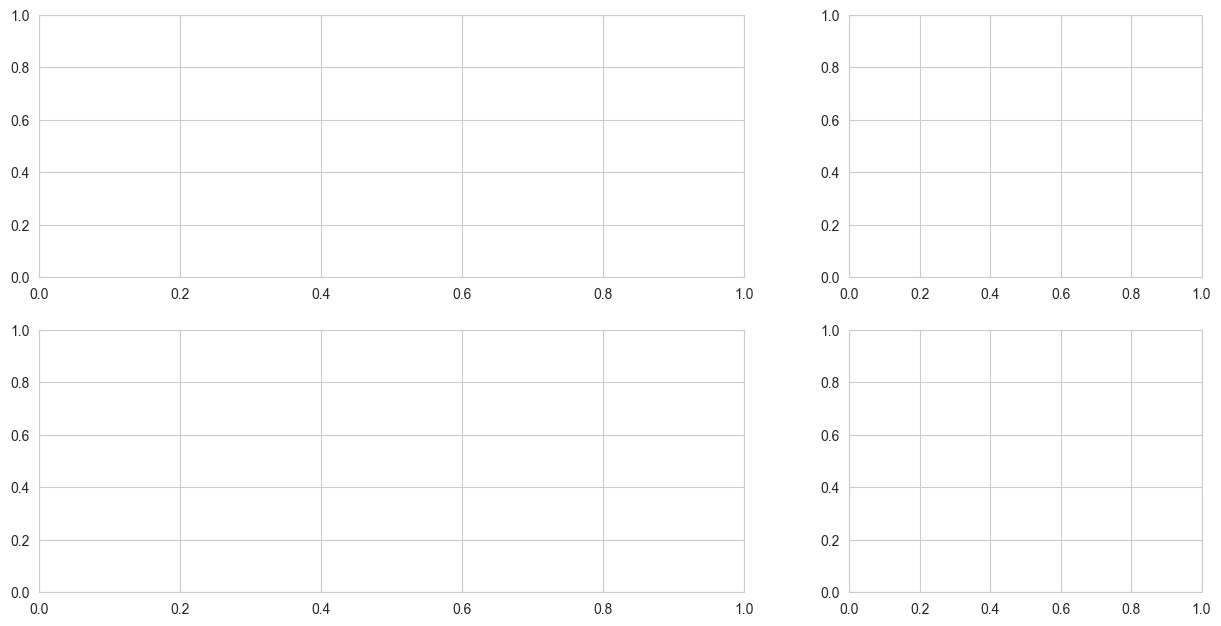

In [28]:
ls_messages = []
print_msg = True

if result_display:
    ls_messages = adding_plot_and_text("\n" + "="*100, ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"RESULTS for {example_model} - {location_choice}", ls_messages, print_msg)
    ls_messages = adding_plot_and_text("="*100, ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"\nAnnual maxima: {len(result_display['annual_maxima'])} years", ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"Observations per year: ~2 (from ensemble members)", ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"Total data points for GEV: {result_display['gev_stationary']['n_obs']}", ls_messages, print_msg)

    ls_messages = adding_plot_and_text("\nSTATIONARY GEV", ls_messages, print_msg)
    stat = result_display['gev_stationary']
    ls_messages = adding_plot_and_text(f"  μ (location) = {stat['location']:.3f}", ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"  σ (scale) = {stat['scale']:.3f}", ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"  ξ (shape) = {stat['shape']:.3f}", ls_messages, print_msg)
    ls_messages = adding_plot_and_text(f"  Type: {stat['dist_type']}", ls_messages, print_msg)

    if result_display['gev_nonstationary']:
        ls_messages = adding_plot_and_text("\nNON-STATIONARY GEV", ls_messages, print_msg)
        nonstat = result_display['gev_nonstationary']
        ls_messages = adding_plot_and_text(f"  μ(t) = {nonstat['mu0']:.3f} + {nonstat['mu1']:.4f}·t", ls_messages, print_msg)
        ls_messages = adding_plot_and_text(f"  Trend = {nonstat['mu1'] * nonstat['years_std']:.4f} m/year", ls_messages, print_msg)

    if result_display['model_comparison']:
        ls_messages = adding_plot_and_text("\nMODEL COMPARISON", ls_messages, print_msg)
        comp = result_display['model_comparison']
        ls_messages = adding_plot_and_text(f"  p-value: {comp['p_value']:.4f}", ls_messages, print_msg)
        ls_messages = adding_plot_and_text(f"  Decision: {comp['decision']}", ls_messages, print_msg)
        ls_messages = adding_plot_and_text(f"  → {comp['recommendation']}", ls_messages, print_msg)

    # Store messages (GEV analysis parameters) as txt
    today_ = str(datetime.today().date().isoformat())
    save_path = path_export + today_
    Path(save_path).mkdir(parents=True, exist_ok=True)
    location = '-'.join([
        result_display['location info'].split(',')[0].strip(), 
        result_display['location info'].split(',')[-1].strip()
        ])
            
    with open(save_path + f"/GEVanalysis_{example_model}_{location}_{today_}.txt", 'w') as f:
        f.write('\n'.join(ls_messages))
    
    print("\nVISUALIZE RESULTS")
    dbplt.plot_analysis(
        results=results, 
        model=example_model, 
        lat_lon_tuple=result_display['location'], 
        location_info=result_display['location info'],
        periods_evolution = ['10-year', '50-year', '100-year'],
        box_parameters_x=0.05, box_parameters_y=0.95,
        width_bar_returns=0.35,
        leg_comparison_x=0.35, leg_comparison_y=0.65, linespace=1.5,
        save_path = save_path,
        color_markers='#99E3DDFF', 
        colors_trends='#1D141BFF', 
        colors_models=['#B887ADFF', '#008A80FF'],
        colors_return_levels=['#008A80FF','#CAA5C2FF'],
        bbox_color='#F5F5F5FF',
        axes_color='#333333', 
        linestyle_trends=['dashdot', 'dashed', 'solid'], 
        fontsize=12, figsize=(15, 7.5),
    )

#### Annual Maximum Storm Surge

In [ ]:
result = results[example_model][result_display['location']]

fig1, ax1 = plt.subplots(figsize=(13, 3.5))
dbplt.plot_annual_max_with_trends(
        annual_max=result['annual_maxima'], 
        result=result,
        nonstat=result['gev_nonstationary'],
        comp=result['model_comparison'],
        colors_trends='#333333', 
        linestyle_trends=['solid', 'dashdot', 'dashed'], 
        axes_color='#333333', 
        color_markers='#99E3DDFF', ms=6, fontsize=15, ax=ax1, 
        )

#### Model Comparison

In [ ]:
fig2, ax2 = plt.subplots(figsize=(5, 3.5))
dbplt.plot_model_comparison(
    comp=result['model_comparison'], 
    stat=result['gev_stationary'], 
    nonstat=result['gev_nonstationary'], 
    models_names=['Stationary', 'Non-Stationary'], 
    colors_models=['#B887ADFF', '#008A80FF'], bbox_color='#F5F5F5FF', 
    ax=ax2, fontsize=12
    )

#### Return Level

In [ ]:
fig3, ax3 = plt.subplots(figsize=(8, 3.5))
dbplt.plot_level_evolution(
        result=result, periods=['10-year', '50-year', '100-year'], color_levels=['#008A80FF','#CAA5C2FF'], width=0.35, fontsize=10, axes_color='#333333', ax=ax3)

#### Analysis Parameters Summary

In [ ]:
fig4, ax4 = plt.subplots(figsize=(8, 3.5))
dbplt.create_parameter_summary(
    stat=stat, nonstat=nonstat, comp=comp, box_x=0.05, box_y=0.95, ax=ax4, fontsize=9, linespace=1.5,
    bbox=dict(boxstyle='round', facecolor='#F5F5F5FF', alpha=0.5)
    )